# Customer Churn Analysis

## Exploratory Data Analysis


## Objective

The objective of this exploratory data analysis (EDA) is to identify the key factors influencing customer churn.

This analysis explores customer demographics, subscribed services, contract details, billing behavior, and customer tenure to uncover patterns associated with churn.

The insights generated from this analysis will guide feature selection for predictive modeling and provide actionable business recommendations for improving customer retention.

In [2]:
# Standard Library
import sys
from pathlib import Path

# Third-party Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project Modules
sys.path.append(str(Path().resolve().parent))


from src.analysis import create_churn_summary
from src.visualization import plot_churn_rate_bar

from src.analysis import create_bivariate_churn_summary 
from src.visualization import plot_bivariate_churn_rate

from src.analysis import create_segment_summary
from src.visualization import plot_top_segments


In [3]:

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [4]:
df = pd.read_excel("/Users/ashwathimd/DataLab/Projects/customer-churn-analysis/data/processed/telco_customer_churn_clean.xlsx")

In [5]:
df.shape

(7043, 29)

In [6]:
df.head()

,CustomerID,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   City               7043 non-null   str    
 2   Zip Code           7043 non-null   int64  
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   str    
 6   Senior Citizen     7043 non-null   str    
 7   Partner            7043 non-null   str    
 8   Dependents         7043 non-null   str    
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   str    
 11  Multiple Lines     7043 non-null   str    
 12  Internet Service   7043 non-null   str    
 13  Online Security    7043 non-null   str    
 14  Online Backup      7043 non-null   str    
 15  Device Protection  7043 non-null   str    
 16  Tech Support       7043 non-null   

## Business Question 1

### What is the overall customer churn rate?

In [8]:
overall_churn = round(df["Churn Value"].mean() * 100, 2)

total_customers = len(df)
customers_churned = df["Churn Value"].sum()
customers_retained = total_customers - customers_churned

print(f"Total Customers   : {total_customers:,}")
print(f"Customers Churned : {customers_churned:,}")
print(f"Customers Retained: {customers_retained:,}")
print(f"Overall Churn Rate: {overall_churn}%")

Total Customers   : 7,043
Customers Churned : 1,869
Customers Retained: 5,174
Overall Churn Rate: 26.54%


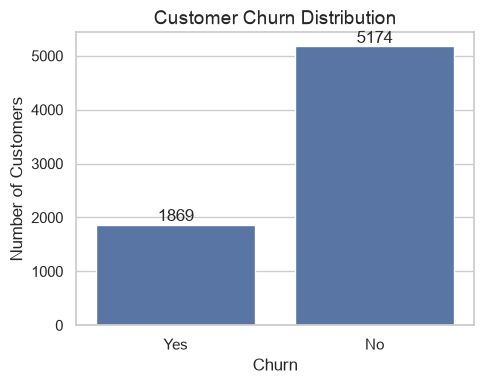

In [9]:
plt.figure(figsize=(5, 4))

ax = sns.countplot(
    data=df,
    x="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Interpretation

- The dataset contains **7,043** customers.
- **1,869** customers have churned, resulting in an overall churn rate of **26.54%**.
- Approximately **1 in 4 customers** leave the company.
- This indicates that customer churn is a meaningful business problem and justifies further investigation into the factors associated with churn.

## Business Question 2

### Does gender influence customer churn?

### Why are we asking this?

Understanding whether customer churn differs by gender helps determine if demographic characteristics play a meaningful role in customer retention. If a substantial difference exists, gender could be considered during customer segmentation and predictive modeling.

In [10]:
gender_analysis = create_churn_summary(df,"Gender")
gender_analysis

,Gender,customer_count,churned,retained,churn_rate
0,Female,3488,939,2549,26.92
1,Male,3555,930,2625,26.16


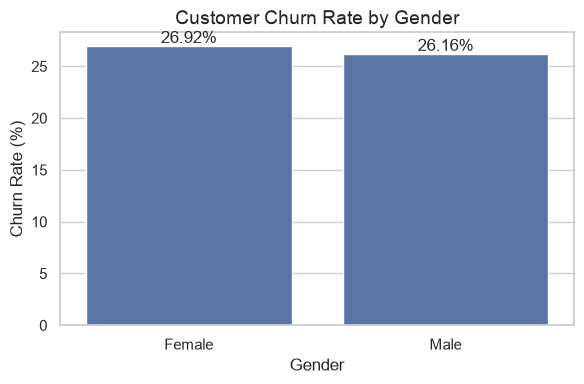

In [11]:
plot_churn_rate_bar(
    gender_analysis,
    "Gender"
)

### Interpretation

- Female customers have a churn rate of **26.92%**, while male customers have a churn rate of **26.16%**.
- The difference between the two groups is only **0.76 percentage points**.
- Both genders have a similar number of customers, making the comparison balanced.
- Gender does not appear to be a strong differentiating factor for customer churn.
- Therefore, gender is unlikely to be a useful standalone predictor of churn and should be considered alongside other customer characteristics.

## Business Question 3

### Are senior citizens more likely to churn?

In [12]:
senior_analysis = create_churn_summary(df, "Senior Citizen")

senior_analysis

,Senior Citizen,customer_count,churned,retained,churn_rate
0,No,5901,1393,4508,23.61
1,Yes,1142,476,666,41.68


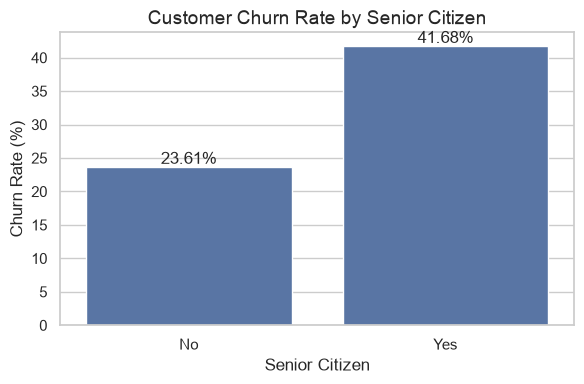

In [13]:
plot_churn_rate_bar(
    senior_analysis,
    "Senior Citizen"
)

### Interpretation

- Senior citizens have a churn rate of **41.68%**, compared to **23.61%** for non-senior customers.
- The churn rate among senior citizens is **15.14 percentage points higher** than the overall customer churn rate (**26.54%**).
- Although senior citizens represent a smaller portion of the customer base (1,142 customers), they exhibit a substantially higher likelihood of churning.
- This suggests that **senior citizen status is strongly associated with customer churn** and may be an important feature for predictive modeling.
- From a business perspective, senior citizens may benefit from targeted retention initiatives, such as personalized customer support, simplified service plans, or loyalty programs.

## Business Question 4

### Does having a partner influence customer churn?

In [14]:
partner_analysis = create_churn_summary(df,"Partner")
partner_analysis

,Partner,customer_count,churned,retained,churn_rate
0,No,3641,1200,2441,32.96
1,Yes,3402,669,2733,19.66


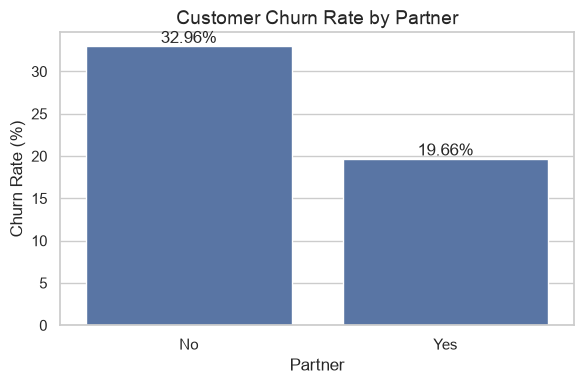

In [15]:
plot_churn_rate_bar(
    partner_analysis,
    "Partner"
)

### Interpretation

- Customers without a partner have a churn rate of **32.96%**, whereas customers with a partner have a churn rate of **19.66%**.
- Customers without a partner churn at a rate **6.42 percentage points higher** than the overall churn rate (**26.54%**).
- In contrast, customers with a partner have a churn rate that is **6.88 percentage points lower** than the overall average.
- This suggests that **having a partner is associated with lower customer churn** and may contribute to greater customer retention.
- Therefore, partner status appears to be a meaningful feature for predicting churn and may help identify customers at higher risk of leaving.

## Business Question 5

### Do customers with dependents have different churn behavior?

In [16]:
dependancy_analysis = create_churn_summary(df,"Dependents")
dependancy_analysis

,Dependents,customer_count,churned,retained,churn_rate
0,No,5416,1763,3653,32.55
1,Yes,1627,106,1521,6.52


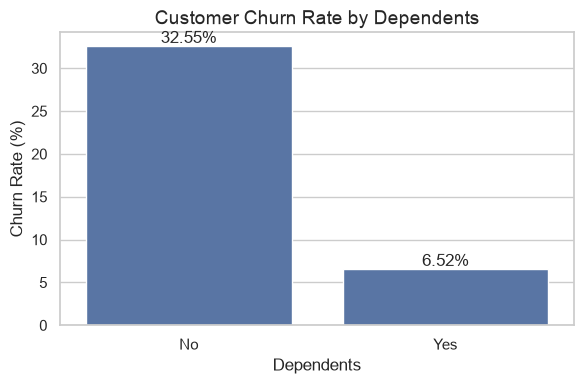

In [17]:
plot_churn_rate_bar(
    dependancy_analysis,
    "Dependents"
)

### Interpretation

- Customers without dependents have a churn rate of **32.55%**, whereas customers with dependents have a churn rate of only **6.52%**.
- Customers without dependents churn at a rate **6.01 percentage points higher** than the overall churn rate (**26.54%**).
- In contrast, customers with dependents have a churn rate **20.02 percentage points lower** than the overall average.
- This indicates that **customers without dependents are considerably more likely to churn** than those with dependents.
- Therefore, dependent status appears to be a strong predictor of customer churn and may help identify customers who require proactive retention strategies.

## Business Question 6

### Does phone service influence customer churn?

In [18]:
phone_analysis = create_churn_summary(df,"Phone Service")
phone_analysis

,Phone Service,customer_count,churned,retained,churn_rate
0,No,682,170,512,24.93
1,Yes,6361,1699,4662,26.71


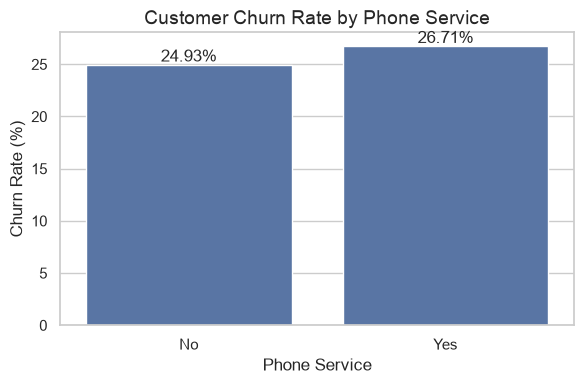

In [19]:
plot_churn_rate_bar(
    phone_analysis,
    "Phone Service"
)

### Interpretation

- Customers without phone service have a churn rate of **24.93%**, while customers with phone service have a churn rate of **26.71%**.
- The difference between the two groups is only **1.78 percentage points**.
- Both churn rates are close to the overall customer churn rate (**26.54%**).
- This suggests that **phone service alone is not a strong differentiating factor for customer churn**.
- Therefore, phone service is unlikely to be a useful standalone predictor of churn and should be evaluated alongside other customer characteristics.

## Business Question 7

### Does having multiple phone lines influence customer churn?

In [20]:
multiple_lines_analysis = create_churn_summary(df,"Multiple Lines")
multiple_lines_analysis

,Multiple Lines,customer_count,churned,retained,churn_rate
0,No,3390,849,2541,25.04
1,No phone service,682,170,512,24.93
2,Yes,2971,850,2121,28.61


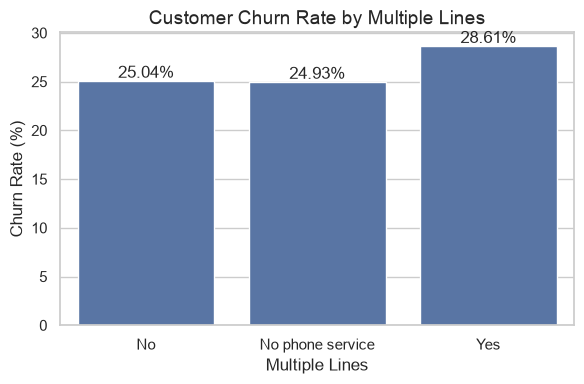

In [21]:
plot_churn_rate_bar(
    multiple_lines_analysis,
    "Multiple Lines"
)

### Interpretation

- Customers with multiple phone lines have a churn rate of **28.61%**, compared to **25.04%** for customers with a single phone line and **24.93%** for customers without phone service.
- Customers with multiple lines have a churn rate **2.07 percentage points higher** than the overall churn rate (**26.54%**).
- Although customers with multiple lines exhibit a slightly higher churn rate, the difference is relatively small.
- This suggests that **having multiple phone lines alone is not a strong differentiating factor for customer churn**.
- Therefore, the number of phone lines is unlikely to be a useful standalone predictor of churn and should be considered alongside other customer characteristics.

## Business Question 8

### Does the type of internet service influence customer churn?

In [22]:
internet_type_analysis = create_churn_summary(df,"Internet Service")
internet_type_analysis

,Internet Service,customer_count,churned,retained,churn_rate
0,DSL,2421,459,1962,18.96
1,Fiber optic,3096,1297,1799,41.89
2,No,1526,113,1413,7.40


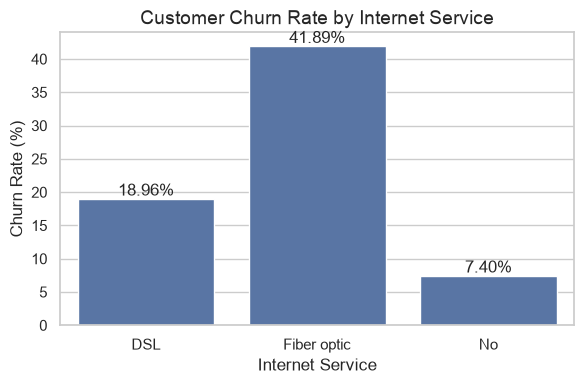

In [23]:
plot_churn_rate_bar(
    internet_type_analysis,
    "Internet Service"
)

### Interpretation

- Customers using **Fiber optic** internet service have the highest churn rate at **41.89%**, which is substantially higher than both **DSL (18.96%)** and customers with **no internet service (7.40%)**.
- The churn rate among Fiber optic customers is **15.35 percentage points higher** than the overall churn rate (**26.54%**).
- In contrast, customers with DSL and those without internet service exhibit significantly lower churn rates than the overall average.
- This suggests that **the type of internet service is strongly associated with customer churn**, with Fiber optic customers being considerably more likely to leave the service.
- Therefore, internet service type appears to be an important predictor of customer churn. Further investigation into factors such as pricing, service quality, customer expectations, or technical issues among Fiber optic customers may help explain this higher churn rate and identify opportunities for targeted retention strategies.

## Business Question 9

### Does online security influence customer churn?

In [24]:
online_security_analysis = create_churn_summary(df,"Online Security")
online_security_analysis

,Online Security,customer_count,churned,retained,churn_rate
0,No,3498,1461,2037,41.77
1,No internet service,1526,113,1413,7.40
2,Yes,2019,295,1724,14.61


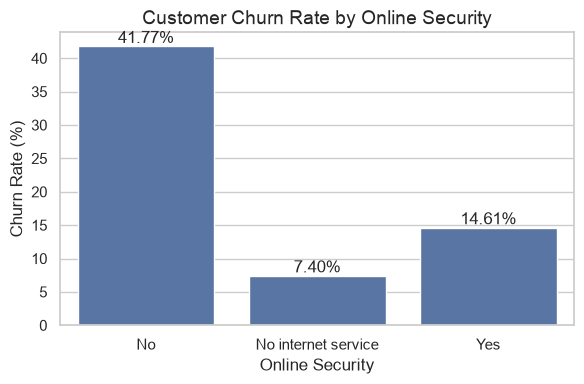

In [25]:
plot_churn_rate_bar(
    online_security_analysis,
    "Online Security"
)

### Interpretation

- Customers without Online Security have a churn rate of **41.77%**, whereas customers with Online Security have a churn rate of only **14.61%**.
- Customers without Online Security churn at a rate **15.23 percentage points higher** than the overall churn rate (**26.54%**).
- Customers with Online Security exhibit a churn rate **11.93 percentage points lower** than the overall average.
- This indicates that **Online Security is strongly associated with customer churn**, with customers lacking this service being substantially more likely to leave.
- Therefore, Online Security appears to be an important predictor of customer churn. Encouraging customers to adopt security services may increase customer engagement and contribute to improved retention.

## Business Question 10

### Does online backup influence customer churn?

In [26]:
online_backup_analysis = create_churn_summary(df,"Online Backup")
online_backup_analysis

,Online Backup,customer_count,churned,retained,churn_rate
0,No,3088,1233,1855,39.93
1,No internet service,1526,113,1413,7.40
2,Yes,2429,523,1906,21.53


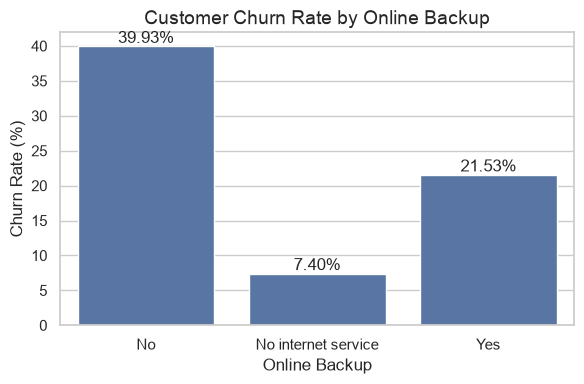

In [27]:
plot_churn_rate_bar(
    online_backup_analysis,
    "Online Backup"
)

### Interpretation

- Customers without Online Backup have a churn rate of **39.93%**, whereas customers with Online Backup have a churn rate of **21.53%**.
- Customers without Online Backup churn at a rate **13.39 percentage points higher** than the overall churn rate (**26.54%**).
- Customers with Online Backup exhibit a churn rate **5.01 percentage points lower** than the overall average.
- This indicates that **Online Backup is strongly associated with customer churn**, with customers lacking this service being considerably more likely to leave.
- Therefore, Online Backup appears to be an important predictor of customer churn and may represent an opportunity for customer retention through value-added service adoption.

## Business Question 11

### Does device protection influence customer churn?

In [28]:
device_protection_analysis = create_churn_summary(df,"Device Protection")
device_protection_analysis

,Device Protection,customer_count,churned,retained,churn_rate
0,No,3095,1211,1884,39.13
1,No internet service,1526,113,1413,7.40
2,Yes,2422,545,1877,22.50


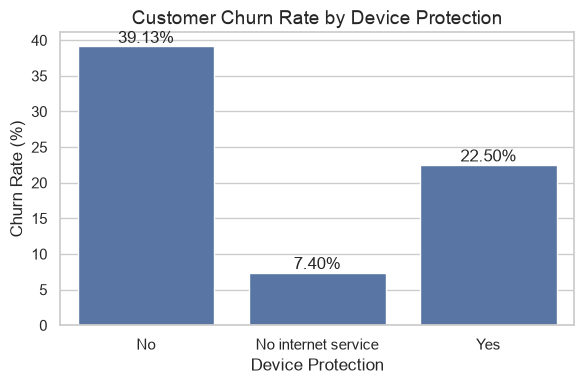

In [29]:
plot_churn_rate_bar(
    device_protection_analysis,
    "Device Protection"
)

### Interpretation

- Customers without Device Protection have a churn rate of **39.13%**, whereas customers with Device Protection have a churn rate of **22.50%**.
- Customers without Device Protection churn at a rate **12.59 percentage points higher** than the overall churn rate (**26.54%**).
- Customers with Device Protection have a churn rate **4.04 percentage points lower** than the overall average.
- This suggests that **Device Protection is strongly associated with customer churn**, with customers lacking this service being considerably more likely to churn.
- Therefore, Device Protection appears to be an important feature for identifying customers at a higher risk of churn.

## Business Question 12

### Does tech support influence customer churn?

In [30]:
tech_support_analysis = create_churn_summary(df,"Tech Support")
tech_support_analysis

,Tech Support,customer_count,churned,retained,churn_rate
0,No,3473,1446,2027,41.64
1,No internet service,1526,113,1413,7.40
2,Yes,2044,310,1734,15.17


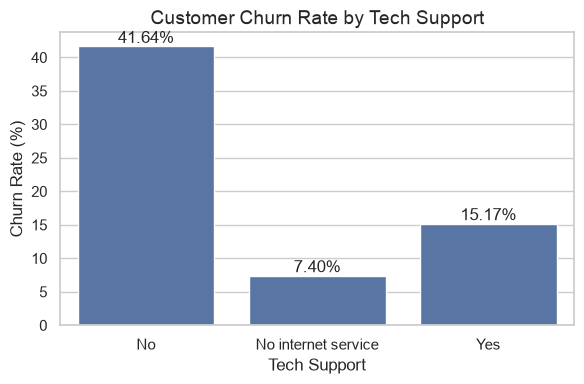

In [31]:
plot_churn_rate_bar(
    tech_support_analysis,
    "Tech Support"
)

### Interpretation

- Customers without Tech Support have a churn rate of **41.64%**, whereas customers with Tech Support have a churn rate of **15.17%**.
- Customers without Tech Support churn at a rate **15.10 percentage points higher** than the overall churn rate (**26.54%**).
- Customers with Tech Support exhibit a churn rate **11.37 percentage points lower** than the overall average.
- This indicates that **Tech Support is strongly associated with customer churn**, with customers lacking technical support being substantially more likely to leave.
- Therefore, Tech Support appears to be one of the strongest predictors of customer churn. Improving customer awareness and adoption of technical support services may contribute to higher customer retention.

## Business Question 13

### Does streaming TV influence customer churn?

In [32]:
streaming_tv_analysis = create_churn_summary(df,"Streaming TV")
streaming_tv_analysis

,Streaming TV,customer_count,churned,retained,churn_rate
0,No,2810,942,1868,33.52
1,No internet service,1526,113,1413,7.40
2,Yes,2707,814,1893,30.07


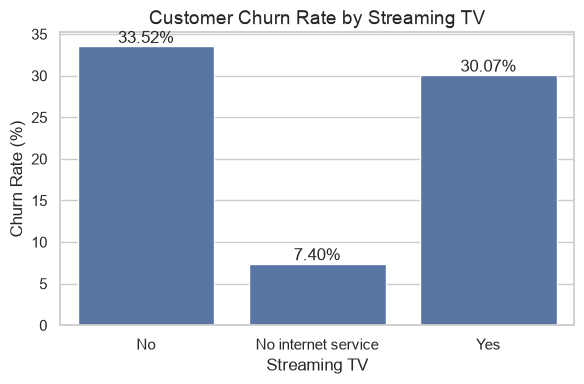

In [33]:
plot_churn_rate_bar(
    streaming_tv_analysis,
    "Streaming TV"
)

### Interpretation

- Customers with Streaming TV have a churn rate of **30.07%**, while customers without Streaming TV have a churn rate of **33.52%**.
- Both customer groups exhibit churn rates that are relatively close to the overall churn rate (**26.54%**).
- The difference between the two groups is only **3.45 percentage points**.
- This suggests that **Streaming TV has only a weak association with customer churn**.
- Therefore, Streaming TV is unlikely to be a major differentiating factor for customer churn when considered in isolation.

## Business Question 14

### Does streaming movies influence customer churn?

In [34]:
streaming_movie_analysis = create_churn_summary(df,"Streaming Movies")
streaming_movie_analysis

,Streaming Movies,customer_count,churned,retained,churn_rate
0,No,2785,938,1847,33.68
1,No internet service,1526,113,1413,7.40
2,Yes,2732,818,1914,29.94


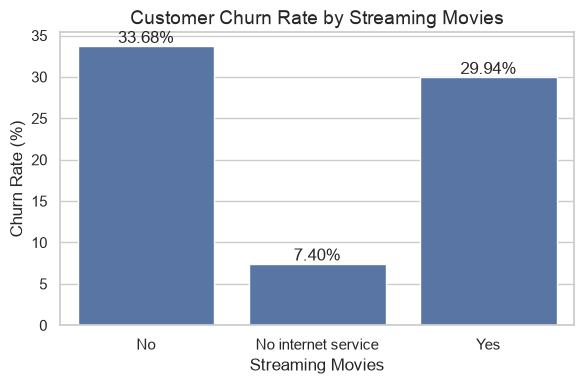

In [35]:
plot_churn_rate_bar(
    streaming_movie_analysis,
    "Streaming Movies"
)

### Interpretation

- Customers with Streaming Movies have a churn rate of **29.94%**, while customers without Streaming Movies have a churn rate of **33.68%**.
- The difference between the two groups is relatively small (**3.74 percentage points**).
- Both groups exhibit churn rates close to the overall customer churn rate (**26.54%**).
- This suggests that **Streaming Movies has only a weak association with customer churn**.
- Therefore, Streaming Movies is unlikely to be a major differentiating factor for customer churn when evaluated independently.

## Business Question 15

### Does the type of contract influence customer churn?

In [36]:
contract_type_analysis = create_churn_summary(df,"Contract")
contract_type_analysis

,Contract,customer_count,churned,retained,churn_rate
0,Month-to-month,3875,1655,2220,42.71
1,One year,1473,166,1307,11.27
2,Two year,1695,48,1647,2.83


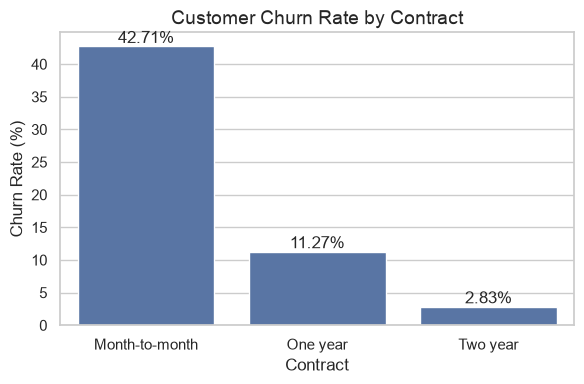

In [37]:
plot_churn_rate_bar(
    contract_type_analysis,
    "Contract"
)

### Interpretation

- Customers on **Month-to-month** contracts have the highest churn rate at **42.71%**, compared to **11.27%** for **One year** contracts and only **2.83%** for **Two year** contracts.
- Customers with Month-to-month contracts churn at a rate **16.17 percentage points higher** than the overall churn rate (**26.54%**).
- Customers with longer-term contracts exhibit substantially lower churn rates, indicating significantly higher customer retention.
- This demonstrates that **contract type is one of the strongest factors associated with customer churn**.
- Therefore, encouraging customers to transition from month-to-month plans to longer-term contracts may be one of the most effective business strategies for reducing customer churn.

## Business Question 16

### Does paperless billing influence customer churn?

In [38]:
paperless_billing_analysis = create_churn_summary(df,"Paperless Billing")
paperless_billing_analysis

,Paperless Billing,customer_count,churned,retained,churn_rate
0,No,2872,469,2403,16.33
1,Yes,4171,1400,2771,33.57


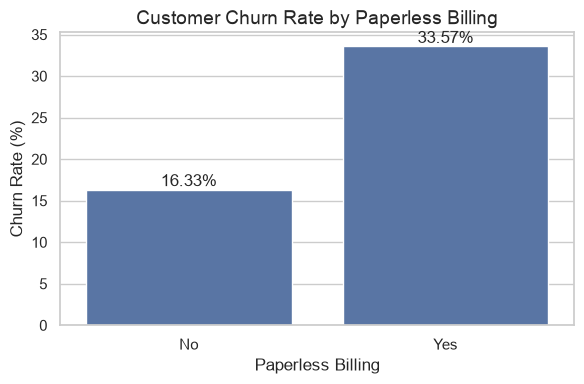

In [39]:
plot_churn_rate_bar(
    paperless_billing_analysis,
    "Paperless Billing"
)

### Interpretation

- Customers using Paperless Billing have a churn rate of **33.57%**, whereas customers who do not use Paperless Billing have a churn rate of **16.33%**.
- Customers with Paperless Billing churn at a rate **7.03 percentage points higher** than the overall churn rate (**26.54%**).
- In contrast, customers without Paperless Billing exhibit a churn rate **10.21 percentage points lower** than the overall average.
- This suggests that **Paperless Billing is moderately associated with customer churn**.
- While Paperless Billing itself may not directly cause churn, it appears to be associated with customer segments that are more likely to leave the service.

## Business Question 17

### Does the payment method influence customer churn?

In [40]:
payment_method_analysis = create_churn_summary(df,"Payment Method")
payment_method_analysis

,Payment Method,customer_count,churned,retained,churn_rate
0,Bank transfer (automatic),1544,258,1286,16.71
1,Credit card (automatic),1522,232,1290,15.24
2,Electronic check,2365,1071,1294,45.29
3,Mailed check,1612,308,1304,19.11


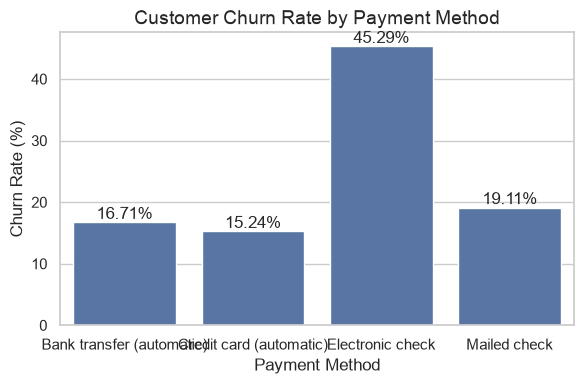

In [41]:
plot_churn_rate_bar(
    payment_method_analysis,
    "Payment Method"
)

### Interpretation

- Customers using **Electronic check** have the highest churn rate at **45.29%**, considerably higher than customers using **Bank transfer (16.71%)**, **Credit card (15.24%)**, or **Mailed check (19.11%)**.
- The churn rate among customers using Electronic check is **18.75 percentage points higher** than the overall churn rate (**26.54%**).
- Customers using automatic payment methods exhibit substantially lower churn rates than those using Electronic check.
- This indicates that **payment method is strongly associated with customer churn**, with Electronic check customers representing the highest-risk payment segment.
- Therefore, encouraging customers to adopt automatic payment methods may help improve customer retention and reduce churn.

# Numerical Feature Analysis

In this section, we examine continuous variables to understand how customer tenure and spending patterns are associated with customer churn.



## Business Question 18

### Does customer tenure influence customer churn?

In [42]:
df["Tenure Months"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure Months, dtype: float64

In [43]:
tenure_bins = [0,12,24,36,48,60,72]

tenure_labels = [
    "0 - 12 months",
    "13 - 24 months",
    "25 - 36 months",
    "37 - 48 months",
    "49 - 60 months",
    "61 - 72 months" 
]

df["Tenure Band"] = pd.cut(
    df["Tenure Months"],
    bins = tenure_bins,
    labels = tenure_labels,
    include_lowest= True
)

df["Tenure Band"].value_counts().sort_index()

Tenure Band
0 - 12 months     2186
13 - 24 months    1024
25 - 36 months     832
37 - 48 months     762
49 - 60 months     832
61 - 72 months    1407
Name: count, dtype: int64

In [44]:
tenure_summary = create_churn_summary(df,"Tenure Band")
tenure_summary

,Tenure Band,customer_count,churned,retained,churn_rate
0,0 - 12 months,2186,1037,1149,47.44
1,13 - 24 months,1024,294,730,28.71
2,25 - 36 months,832,180,652,21.63
3,37 - 48 months,762,145,617,19.03
4,49 - 60 months,832,120,712,14.42
5,61 - 72 months,1407,93,1314,6.61


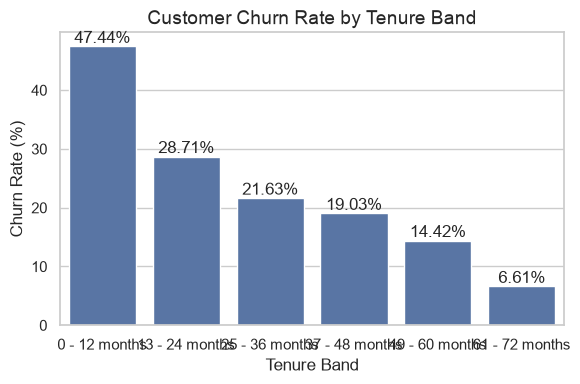

In [45]:


plot_churn_rate_bar(
    tenure_summary,
    "Tenure Band"
)

### Business Insight

Customer tenure has a strong inverse relationship with churn. Customers are most likely to leave during the early months of their relationship with the company, and the likelihood of churn steadily decreases as tenure increases.

- Customers with **0–12 months** of tenure have the highest churn rate (**47.44%**), meaning nearly one in two new customers leave within their first year.
- Churn drops sharply to **28.71%** for customers with **13–24 months** of tenure and continues to decline across subsequent tenure bands.
- Long-term customers are significantly more loyal, with customers in the **61–72 months** tenure band showing the lowest churn rate (**6.61%**).

These findings suggest that the first year of the customer lifecycle is the most critical period for retention. Improving onboarding, customer engagement, and proactive support during the initial months could have the greatest impact on reducing overall churn.

## Business Question 19

### Do customers with higher monthly charges have a higher churn rate?

In [46]:
df["Monthly Charges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [47]:
df["Monthly Charges"].quantile([0, 0.25, 0.5, 0.75, 1])

0.00     18.25
0.25     35.50
0.50     70.35
0.75     89.85
1.00    118.75
Name: Monthly Charges, dtype: float64

In [48]:
monthly_charges_bins = [18, 40, 60, 80, 100, 120]

monthly_charges_labels = [
    "Low ($18-40)",
    "Lower-Mid ($40-60)",
    "Mid ($60-80)",
    "Upper-Mid ($80-100)",
    "High ($100-120)"
]

df["Monthly_Charges_Band"] = pd.cut(
    df["Monthly Charges"],
    bins=monthly_charges_bins,
    labels=monthly_charges_labels,
    include_lowest=True
)
df["Monthly_Charges_Band"].value_counts().sort_index()

Monthly_Charges_Band
Low ($18-40)           1838
Lower-Mid ($40-60)     1080
Mid ($60-80)           1459
Upper-Mid ($80-100)    1764
High ($100-120)         902
Name: count, dtype: int64

In [49]:
monthly_charge_summary = create_churn_summary(df,"Monthly_Charges_Band")
monthly_charge_summary

,Monthly_Charges_Band,customer_count,churned,retained,churn_rate
0,Low ($18-40),1838,214,1624,11.64
1,Lower-Mid ($40-60),1080,276,804,25.56
2,Mid ($60-80),1459,473,986,32.42
3,Upper-Mid ($80-100),1764,653,1111,37.02
4,High ($100-120),902,253,649,28.05


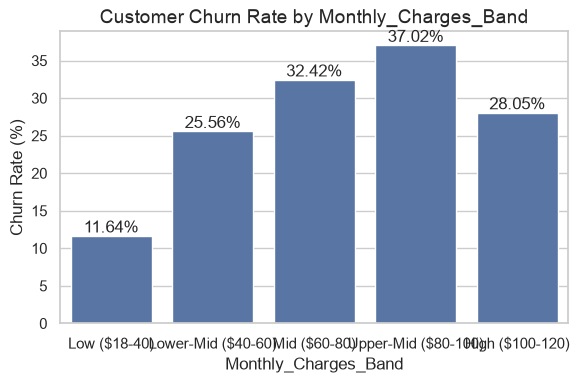

In [50]:
plot_churn_rate_bar(
    monthly_charge_summary,
    "Monthly_Charges_Band"
    )

### Business Insight

Monthly charges show a strong relationship with customer churn. In general, churn increases as monthly charges rise, although the highest-priced customer segment shows a slight decline compared to the upper-mid pricing tier.

- Customers paying **$18–40 per month** have the lowest churn rate (**11.64%**), indicating that lower-priced plans are associated with higher customer retention.
- Churn increases steadily across the next pricing tiers, reaching **25.56%** for customers paying **$40–60**, **32.42%** for **$60–80**, and peaking at **37.02%** for customers paying **$80–100** per month.
- Customers in the highest pricing tier (**$100–120**) experience a lower churn rate (**28.05%**) than the upper-mid tier, suggesting that customers paying the highest prices may perceive greater value from premium services or are more committed despite the higher cost.

Overall, the analysis indicates that customers with higher monthly charges are generally more likely to churn than those on lower-priced plans. This suggests that pricing, perceived value, and service quality should be evaluated together for customers in the mid-to-high pricing segments, particularly those paying between **$80 and $100** per month, where churn is highest.

## Business Question 20

### Do customers with higher total charges have a higher or lower churn rate?

In [51]:
df["Total Charges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: Total Charges, dtype: float64

In [52]:
df["Total Charges"].head()

0     108.15
1     151.65
2     820.50
3    3046.05
4    5036.30
Name: Total Charges, dtype: float64

In [53]:
total_charges_bins = [0,500,1500,3000,5000,9000]

total_charges_labels = [
    "Low ($0-500)",
    "Lower-Mid ($500-1,500)",
    "Mid ($1,500-3,000)",
    "Upper-Mid ($3,000-5,000)",
    "High ($5,000+)"
]

df["Total_Charges_Band"] = pd.cut(
    df["Total Charges"],
    bins = total_charges_bins,
    labels = total_charges_labels
)

df["Total_Charges_Band"].value_counts().sort_index()

Total_Charges_Band
Low ($0-500)                2000
Lower-Mid ($500-1,500)      1661
Mid ($1,500-3,000)          1167
Upper-Mid ($3,000-5,000)    1069
High ($5,000+)              1135
Name: count, dtype: int64

In [54]:
total_charges_summary = create_churn_summary(df,"Total_Charges_Band")
total_charges_summary

,Total_Charges_Band,customer_count,churned,retained,churn_rate
0,Low ($0-500),2000,829,1171,41.45
1,"Lower-Mid ($500-1,500)",1661,412,1249,24.80
2,"Mid ($1,500-3,000)",1167,278,889,23.82
3,"Upper-Mid ($3,000-5,000)",1069,193,876,18.05
4,"High ($5,000+)",1135,157,978,13.83


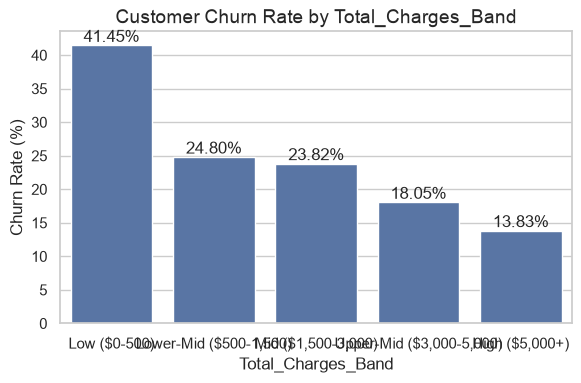

In [55]:
plot_churn_rate_bar(
    total_charges_summary,
    "Total_Charges_Band"
)

### Business Insight

Customers with lower total charges exhibit significantly higher churn rates, while churn steadily decreases as customers accumulate greater lifetime spending with the company.

- Customers with **total charges below $500** have the highest churn rate (**41.45%**), indicating that customers in the early stages of their relationship with the company are the most likely to leave.
- Churn decreases consistently across higher spending bands, falling to **24.80%** for customers with total charges between **$500–1,500**, **23.82%** for **$1,500–3,000**, **18.05%** for **$3,000–5,000**, and reaching the lowest rate (**13.83%**) among customers who have spent **more than $5,000**.
- The results suggest that customers who remain with the company longer and accumulate higher lifetime spending become increasingly loyal and are less likely to churn.

Overall, the analysis indicates a strong inverse relationship between total charges and churn. However, this pattern is likely driven by **customer tenure**, as customers with lower total charges are typically newer customers who have had less time to build loyalty. This reinforces the earlier finding that customer retention efforts should focus on the initial stages of the customer lifecycle, where the risk of churn is highest.

## Key Churn Indicators Identified from Univariate Analysis

Based on the univariate analysis, the following factors appear to have varying levels of association with customer churn.

### Strong Indicators

These features exhibit substantial differences in churn rates across their categories, suggesting a strong relationship with customer churn.

- **Contract Type** – Customers on month-to-month contracts have significantly higher churn rates than those on one-year or two-year contracts.
- **Tenure** – Churn is highest during the first year of a customer's lifecycle and decreases steadily as customer tenure increases.
- **Internet Service Type** – Fiber optic customers experience considerably higher churn than DSL or customers without internet service.
- **Online Security** – Customers without online security are substantially more likely to churn.
- **Tech Support** – Customers without technical support show significantly higher churn rates.
- **Paperless Billing** – Customers enrolled in paperless billing churn at more than twice the rate of those who are not.
- **Payment Method** – Customers using electronic checks have the highest churn rates among all payment methods.
- **Dependents** – Customers without dependents are much more likely to churn than customers with dependents.
- **Partner Status** – Customers without a partner exhibit considerably higher churn rates.

---

### Moderate Indicators

These features demonstrate noticeable differences in churn rates but are less influential than the strongest indicators.

- **Monthly Charges** – Churn generally increases as monthly charges rise, particularly in the mid-to-high pricing tiers.
- **Total Charges** – Customers with lower lifetime spending exhibit higher churn, largely reflecting the higher churn among newer customers.
- **Senior Citizen** – Senior citizens experience higher churn than non-senior customers.
- **Online Backup** – Customers without online backup are more likely to churn.
- **Device Protection** – Lack of device protection is associated with higher churn.
- **Streaming TV** – Customers without streaming TV show slightly higher churn.
- **Streaming Movies** – Customers without streaming movies also exhibit moderately higher churn.

---

### Weak Indicators

These variables show little to no meaningful difference in churn rates and are unlikely to be strong standalone predictors.

- **Gender** – Male and female customers have nearly identical churn rates.
- **Phone Service** – Having phone service does not appear to meaningfully influence churn.
- **Multiple Lines** – Customers with and without multiple lines exhibit very similar churn rates.

---

### Summary

The univariate analysis indicates that **customer commitment (contract type and tenure), internet-related services (internet service, online security, and technical support), and billing behavior (paperless billing and payment method)** are the strongest indicators of customer churn. In contrast, demographic characteristics such as gender and basic phone service have little influence on whether a customer is likely to churn.

These findings are based on descriptive analysis and identify potential relationships with churn. The next phase of the analysis will use statistical methods to determine whether these observed differences are statistically significant and to evaluate the relative importance of each feature.

# Bivariate Analysis

## Objective

To explore how combinations of key customer attributes influence churn and identify interactions that cannot be observed through univariate analysis alone. This analysis aims to uncover customer groups that exhibit significantly different churn behaviors and generate deeper business insights for targeted retention strategies.

---

## Business Question 21

### How does customer tenure influence customer churn across different contract types?

In [56]:
tenure_contract_summary = create_bivariate_churn_summary(
        df,
        "Tenure Band",
        "Contract"
)
tenure_contract_summary


,Tenure Band,Contract,customer_count,churned,retained,churn_rate
0,0 - 12 months,Month-to-month,1994,1024,970,51.35
1,0 - 12 months,One year,124,13,111,10.48
2,0 - 12 months,Two year,68,0,68,0.00
3,13 - 24 months,Month-to-month,737,278,459,37.72
4,13 - 24 months,One year,197,16,181,8.12
5,13 - 24 months,Two year,90,0,90,0.00
6,25 - 36 months,Month-to-month,486,158,328,32.51
7,25 - 36 months,One year,250,20,230,8.00
8,25 - 36 months,Two year,96,2,94,2.08
9,37 - 48 months,Month-to-month,316,106,210,33.54


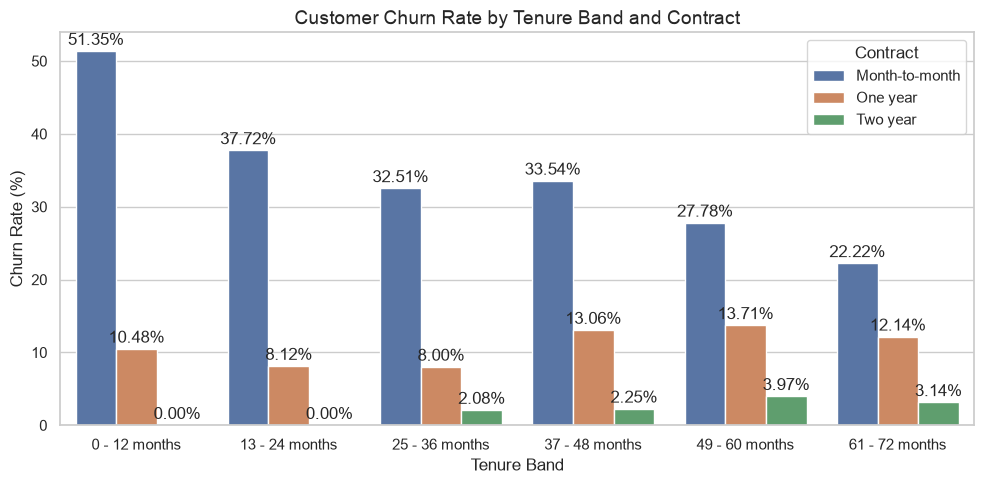

In [57]:
plot_bivariate_churn_rate(
    tenure_contract_summary,
    x = "Tenure Band",
    hue = "Contract"
    
)

### Key Observations

- Customers on **month-to-month contracts** consistently exhibit the highest churn rates across every tenure band, with churn peaking at **51.35%** during the first 12 months. Although churn generally declines as tenure increases, it remains substantially higher than other contract types throughout the customer lifecycle.

- Customers on **one-year contracts** maintain relatively low churn rates, ranging from **8.00% to 13.71%**, indicating much stronger customer retention compared to month-to-month contracts.

- Customers on **two-year contracts** demonstrate the lowest churn rates across all tenure bands, remaining below **4%** in nearly every group and reaching **0%** during the first two years of customer tenure.

- The highest-risk customer segment consists of **new customers (0–12 months) on month-to-month contracts**, while customers on **two-year contracts** represent the most loyal customer segment regardless of tenure.

### Business Insight

The analysis indicates that **contract type is the dominant driver of customer churn, while customer tenure reinforces this relationship**. Although churn generally decreases as customers remain with the company for longer periods, customers on month-to-month contracts continue to exhibit significantly higher churn than customers on one-year and two-year contracts across every tenure band.

These findings suggest that retention strategies should prioritize **new and existing month-to-month customers**, particularly during their first year of service. Encouraging customers to transition to longer-term contracts may substantially improve customer retention and reduce overall churn.

## Business Question 22

### Does technical support reduce customer churn across different internet service types?

In [58]:
support_service_summary = create_bivariate_churn_summary(df,"Tech Support","Internet Service")
support_service_summary


,Tech Support,Internet Service,customer_count,churned,retained,churn_rate
0,No,DSL,1243,345,898,27.76
1,No,Fiber optic,2230,1101,1129,49.37
2,No internet service,No,1526,113,1413,7.40
3,Yes,DSL,1178,114,1064,9.68
4,Yes,Fiber optic,866,196,670,22.63


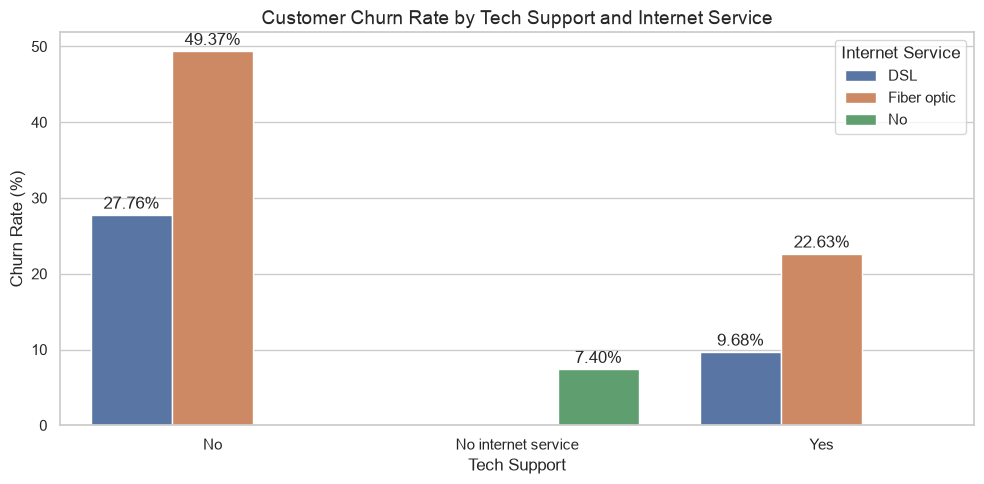

In [59]:
plot_bivariate_churn_rate(
    support_service_summary,
    x = "Tech Support",
    hue = "Internet Service"
)

### Key Observations

- Customers with **fiber optic internet and no technical support** exhibit the highest churn rate at **49.37%**, making them the highest-risk customer group in this analysis.

- Providing **technical support** is associated with a substantial reduction in churn for **fiber optic customers**, lowering the churn rate from **49.37%** to **22.63%**, a decrease of approximately **26.7 percentage points**.

- Among **DSL customers**, technical support is also associated with lower churn, reducing the churn rate from **27.76%** to **9.68%**.

- Customers without an internet service naturally exhibit the lowest churn rate (**7.40%**), as technical support is not applicable to this customer segment.

### Business Insight

Technical support appears to be a significant factor in improving customer retention across internet service types, with the greatest impact observed among **fiber optic customers**. Although fiber optic customers continue to exhibit higher churn than DSL customers, providing technical support is associated with a substantial reduction in churn.

These findings suggest that expanding technical support adoption—particularly among **fiber optic customers who currently lack support**—could represent an effective retention strategy and help reduce customer churn in the company's highest-risk segment.

## Business Question 23

### How do monthly charges influence customer churn across different contract types?

In [60]:
monthlycharges_contract_summary = create_bivariate_churn_summary(df,"Monthly_Charges_Band","Contract")
monthlycharges_contract_summary

,Monthly_Charges_Band,Contract,customer_count,churned,retained,churn_rate
0,Low ($18-40),Month-to-month,762,197,565,25.85
1,Low ($18-40),One year,410,12,398,2.93
2,Low ($18-40),Two year,666,5,661,0.75
3,Lower-Mid ($40-60),Month-to-month,731,254,477,34.75
4,Lower-Mid ($40-60),One year,213,17,196,7.98
5,Lower-Mid ($40-60),Two year,136,5,131,3.68
6,Mid ($60-80),Month-to-month,917,440,477,47.98
7,Mid ($60-80),One year,285,28,257,9.82
8,Mid ($60-80),Two year,257,5,252,1.95
9,Upper-Mid ($80-100),Month-to-month,1141,602,539,52.76


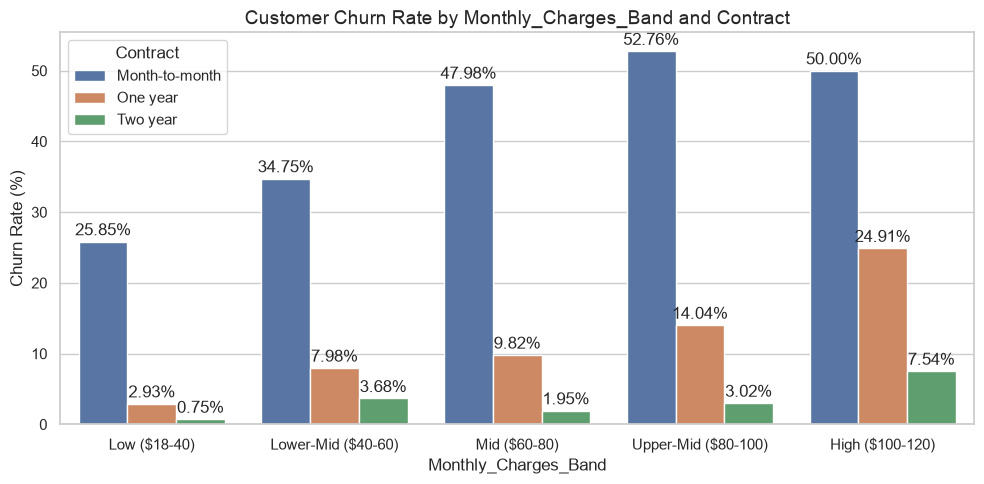

In [61]:
plot_bivariate_churn_rate(
    monthlycharges_contract_summary,
    x = "Monthly_Charges_Band",
    hue = "Contract"
    )

### Key Observations

- Customers on **month-to-month contracts** consistently exhibit the highest churn rates across all monthly charge bands. Churn increases from **25.85%** in the lowest charge band to over **50%** among customers paying between **$80–$120** per month.

- Among **one-year contract** customers, churn remains relatively low across lower monthly charge bands but gradually increases as monthly charges rise, reaching **24.91%** in the highest charge band.

- Customers on **two-year contracts** demonstrate the lowest churn rates across every monthly charge band. Even among customers paying the highest monthly charges, churn remains comparatively low at **7.54%**.

- The impact of higher monthly charges is most pronounced for **month-to-month customers**, whereas customers with longer-term contracts remain significantly less likely to churn despite paying similar monthly fees.

### Business Insight

The relationship between monthly charges and customer churn is strongly influenced by **contract type**. While higher monthly charges are associated with increased churn across all contract types, the effect is substantially greater for customers on **month-to-month contracts**.

These findings suggest that **price sensitivity alone is not the primary driver of churn**. Instead, customers paying higher monthly charges become significantly more likely to leave when they lack the commitment of a long-term contract. Retention efforts should therefore prioritize **high-paying month-to-month customers**, as they represent one of the highest-risk customer segments identified in the analysis.

## Business Question 24

### Does online security reduce customer churn across different internet service types?

In [62]:
security_internet_summary = create_bivariate_churn_summary(df,"Online Security","Internet Service")
security_internet_summary

,Online Security,Internet Service,customer_count,churned,retained,churn_rate
0,No,DSL,1241,347,894,27.96
1,No,Fiber optic,2257,1114,1143,49.36
2,No internet service,No,1526,113,1413,7.40
3,Yes,DSL,1180,112,1068,9.49
4,Yes,Fiber optic,839,183,656,21.81


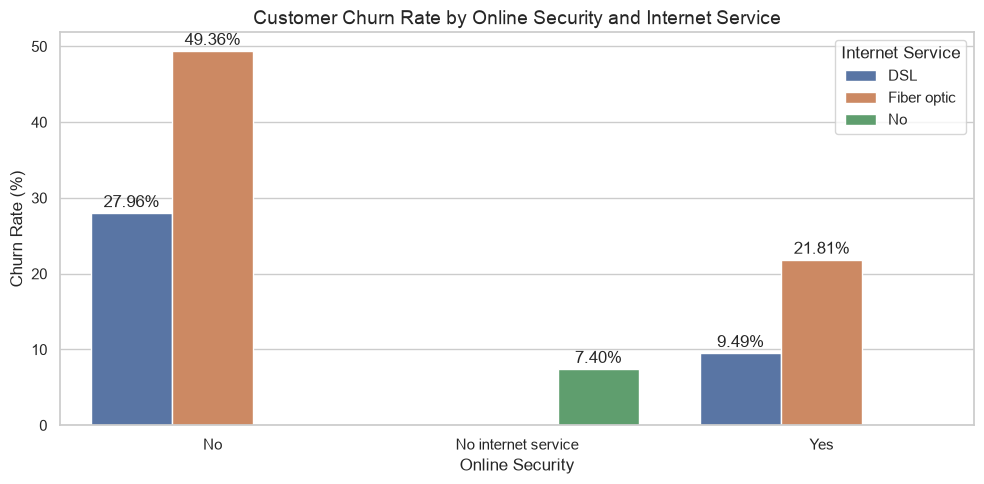

In [63]:
plot_bivariate_churn_rate(
    security_internet_summary,
    x = "Online Security",
    hue = "Internet Service"
)

### Key Observations

- Customers with **fiber optic internet and no online security** exhibit the highest churn rate at **49.36%**, making them the highest-risk customer group in this analysis.

- Among **fiber optic customers**, having **online security** is associated with a substantial reduction in churn, decreasing the churn rate from **49.36%** to **21.81%**, a reduction of approximately **27.55 percentage points**.

- For **DSL customers**, customers with online security also experience significantly lower churn, with the churn rate decreasing from **27.96%** to **9.49%**, a reduction of approximately **18.47 percentage points**.

- Customers without an internet service continue to exhibit the lowest churn rate (**7.40%**), as online security is not applicable to this customer segment.

### Business Insight

Online security appears to be strongly associated with improved customer retention across both DSL and fiber optic internet services. The greatest reduction in churn is observed among **fiber optic customers**, indicating that customers using higher-speed internet services may derive greater value from online security features.

These findings suggest that promoting online security adoption—particularly among **fiber optic customers who currently do not subscribe to the service**—could be an effective strategy for reducing churn within one of the company's highest-risk customer segments.

## Business Question 25

### How does payment method influence customer churn across different contract types?

In [64]:
payment_contract_summmary = create_bivariate_churn_summary(df,"Payment Method","Contract")
payment_contract_summmary

,Payment Method,Contract,customer_count,churned,retained,churn_rate
0,Bank transfer (automatic),Month-to-month,589,201,388,34.13
1,Bank transfer (automatic),One year,391,38,353,9.72
2,Bank transfer (automatic),Two year,564,19,545,3.37
3,Credit card (automatic),Month-to-month,543,178,365,32.78
4,Credit card (automatic),One year,398,41,357,10.30
5,Credit card (automatic),Two year,581,13,568,2.24
6,Electronic check,Month-to-month,1850,994,856,53.73
7,Electronic check,One year,347,64,283,18.44
8,Electronic check,Two year,168,13,155,7.74
9,Mailed check,Month-to-month,893,282,611,31.58


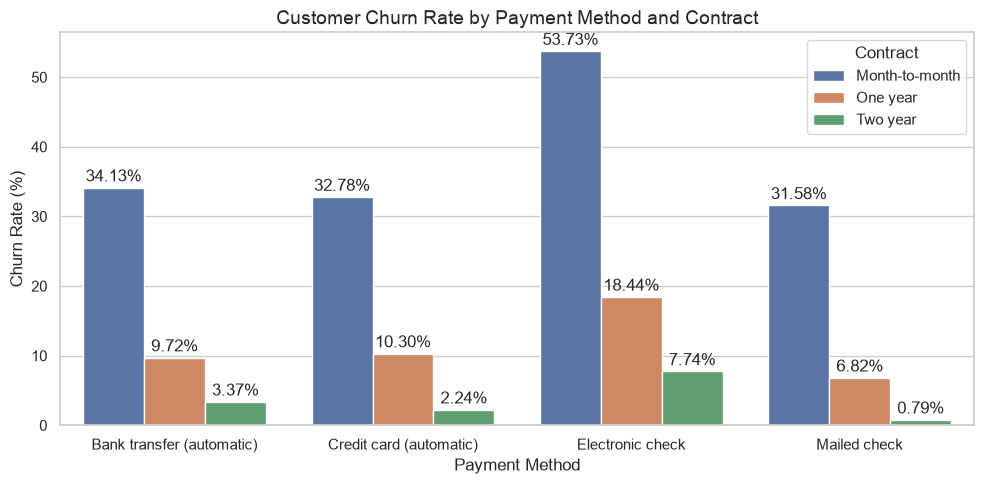

In [65]:
plot_bivariate_churn_rate(
    payment_contract_summmary,
    x = "Payment Method",
    hue = "Contract"
)

### Key Observations

- Customers using **electronic check** consistently exhibit the highest churn rates across all contract types, with churn reaching **53.73%** among month-to-month customers, **18.44%** among one-year contract customers, and **7.74%** among two-year contract customers.

- Among **month-to-month customers**, electronic check users have substantially higher churn than customers using bank transfer (34.13%), credit card (32.78%), or mailed check (31.58%).

- For **one-year contracts**, electronic check continues to have the highest churn rate (**18.44%**), while customers paying via mailed check exhibit the lowest churn (**6.82%**).

- Among **two-year contract** customers, churn remains low across all payment methods. However, electronic check still records the highest churn rate (**7.74%**), whereas mailed check customers experience the lowest churn (**0.79%**).

### Business Insight

Payment method appears to be an important behavioral indicator of customer churn, even after accounting for contract type. Customers using **electronic check** consistently exhibit higher churn than those using other payment methods, suggesting that the relationship is not solely explained by the prevalence of month-to-month contracts.

The combination of **electronic check and month-to-month contracts** represents the highest-risk customer segment identified in this analysis. These customers should be prioritized for proactive retention initiatives, and encouraging migration to automatic payment methods may help improve customer retention.

# Customer Segment Analysis

## Objective

To identify high-risk and low-risk customer segments by combining multiple customer characteristics. This analysis aims to uncover actionable customer profiles that can help the business prioritize retention efforts and develop targeted engagement strategies.

## Business Question 26

### Which customer segment has the highest customer churn rate?

In [66]:
highest_risk_segments = create_segment_summary(
    df,
    grouping_columns=[
        "Contract",
        "Tenure Band",
        "Internet Service",
        "Payment Method"
    ],
    min_customers=30,
    sort_by="churn_rate"
)

highest_risk_segments.head(10)

,Contract,Tenure Band,Internet Service,Payment Method,customer_count,churned,retained,churn_rate
0,Month-to-month,0 - 12 months,Fiber optic,Bank transfer (automatic),87,71,16,81.61
1,Month-to-month,0 - 12 months,Fiber optic,Electronic check,631,449,182,71.16
2,Month-to-month,0 - 12 months,Fiber optic,Mailed check,123,77,46,62.60
3,Month-to-month,0 - 12 months,Fiber optic,Credit card (automatic),75,46,29,61.33
4,Month-to-month,13 - 24 months,Fiber optic,Electronic check,255,150,105,58.82
5,Month-to-month,25 - 36 months,Fiber optic,Electronic check,174,90,84,51.72
6,Month-to-month,0 - 12 months,DSL,Electronic check,282,142,140,50.35
7,Month-to-month,37 - 48 months,Fiber optic,Bank transfer (automatic),49,23,26,46.94
8,Month-to-month,13 - 24 months,Fiber optic,Credit card (automatic),62,28,34,45.16
9,Month-to-month,37 - 48 months,Fiber optic,Electronic check,112,50,62,44.64


### Business Insight

The highest-risk customer segments are overwhelmingly customers on month-to-month contracts, particularly those in the early stages of their relationship and subscribed to Fiber optic internet.

- The highest churn rate (81.61%) is observed among customers with a month-to-month contract, 0–12 months of tenure, Fiber optic internet, and automatic bank transfer payments.
- Multiple high-risk segments share the same characteristics, with the primary differences being payment method, indicating that contract type, tenure, and internet service have a stronger influence on churn than payment method.
- Customers with Fiber optic internet consistently dominate the highest-risk segments, reinforcing earlier findings that this service category experiences substantially higher churn.
- Nearly all top-risk segments belong to customers within the first three years of tenure, suggesting that customer retention efforts should focus heavily on the early stages of the customer lifecycle.

Overall, the analysis indicates that new Fiber optic customers on month-to-month contracts represent the company's most vulnerable customer segments and should be prioritized for proactive retention initiatives.

## Business Question 27

### Which customer segment has the lowest customer churn rate?

In [67]:
lowest_risk_segments = create_segment_summary(
    df,
    grouping_columns=[
        "Contract",
        "Tenure Band",
        "Internet Service",
        "Payment Method"
    ],
    min_customers=30,
    sort_by="churn_rate",
    ascending=True
)

lowest_risk_segments.head(10)

,Contract,Tenure Band,Internet Service,Payment Method,customer_count,churned,retained,churn_rate
0,Two year,61 - 72 months,No,Mailed check,52,0,52,0.00
1,One year,13 - 24 months,No,Mailed check,54,0,54,0.00
2,Two year,0 - 12 months,No,Mailed check,32,0,32,0.00
3,Two year,13 - 24 months,No,Mailed check,44,0,44,0.00
4,Two year,37 - 48 months,No,Mailed check,48,0,48,0.00
5,Two year,61 - 72 months,No,Credit card (automatic),91,0,91,0.00
6,Two year,49 - 60 months,DSL,Credit card (automatic),38,0,38,0.00
7,Two year,61 - 72 months,DSL,Mailed check,46,0,46,0.00
8,Two year,61 - 72 months,No,Bank transfer (automatic),99,0,99,0.00
9,Two year,61 - 72 months,DSL,Bank transfer (automatic),160,2,158,1.25


### Business Insight

The lowest-risk customer segments are dominated by long-tenure customers with longer-term contracts and, in many cases, no internet service.

- Several customer segments experience virtually no churn, with multiple groups reporting a churn rate of 0%.
- Two-year contract customers consistently appear among the lowest-risk segments, confirming that long-term contractual commitment is one of the strongest drivers of customer retention.
- Customers without internet service exhibit exceptionally low churn, suggesting that these customers are generally stable and require fewer retention interventions.
- Long-tenure customers (particularly those with 49–72 months of tenure) remain highly loyal regardless of payment method.

Overall, the analysis suggests that customers with long-term contracts and established relationships with the company require relatively little retention effort, allowing the business to concentrate resources on higher-risk customer groups.

## Business Question 28

### Which high-value customers are most at risk of churn?

In [68]:
high_value_segments = create_segment_summary(
    df,
    grouping_columns=[
        "Monthly_Charges_Band",
        "Contract",
        "Internet Service",
        "Payment Method"
    ],
    min_customers=30,
    sort_by="churn_rate"
)

high_value_segments.head(10)

,Monthly_Charges_Band,Contract,Internet Service,Payment Method,customer_count,churned,retained,churn_rate
0,Mid ($60-80),Month-to-month,Fiber optic,Electronic check,408,269,139,65.93
1,Upper-Mid ($80-100),Month-to-month,Fiber optic,Electronic check,692,409,283,59.10
2,Low ($18-40),Month-to-month,DSL,Electronic check,102,55,47,53.92
3,High ($100-120),Month-to-month,Fiber optic,Electronic check,207,111,96,53.62
4,Upper-Mid ($80-100),Month-to-month,Fiber optic,Mailed check,91,47,44,51.65
5,Mid ($60-80),Month-to-month,Fiber optic,Mailed check,95,49,46,51.58
6,Mid ($60-80),Month-to-month,Fiber optic,Bank transfer (automatic),95,48,47,50.53
7,High ($100-120),Month-to-month,Fiber optic,Credit card (automatic),42,19,23,45.24
8,Upper-Mid ($80-100),Month-to-month,Fiber optic,Bank transfer (automatic),172,75,97,43.60
9,High ($100-120),Month-to-month,Fiber optic,Bank transfer (automatic),60,26,34,43.33


### Business Insight

Among higher-value customers, those with month-to-month contracts and Fiber optic internet exhibit the greatest risk of churn despite generating relatively high monthly revenue.

- The highest-risk high-value segment consists of customers paying $60–80 per month, using Fiber optic internet, paying via Electronic Check, and remaining on month-to-month contracts, with a churn rate of 65.93%.
- Customers in the $80–100 monthly charge band also experience exceptionally high churn rates, particularly when combined with Fiber optic service and month-to-month contracts.
- Electronic Check appears repeatedly among the highest-risk high-value segments, indicating that payment behavior continues to be associated with increased churn.
- High-value customers are not inherently loyal; instead, contract type remains the strongest differentiator of retention.

Overall, the analysis demonstrates that retaining high-value customers requires focusing on those with flexible contracts and Fiber optic internet rather than simply targeting customers with the highest monthly spending.

## Business Question 29

### Which customer segments should be prioritized for retention?

In [73]:
priority_segments = create_segment_summary(
    df,
    grouping_columns=[
        "Contract",
        "Tenure Band",
        "Internet Service",
        "Payment Method"
    ],
    min_customers=50,
    sort_by=[
        "churned",
        "churn_rate"
    ],
    ascending=[
        False,
        False
    ]
)

priority_segments.head(10)

,Contract,Tenure Band,Internet Service,Payment Method,customer_count,churned,retained,churn_rate
0,Month-to-month,0 - 12 months,Fiber optic,Electronic check,631,449,182,71.16
1,Month-to-month,13 - 24 months,Fiber optic,Electronic check,255,150,105,58.82
2,Month-to-month,0 - 12 months,DSL,Electronic check,282,142,140,50.35
3,Month-to-month,0 - 12 months,DSL,Mailed check,255,102,153,40.00
4,Month-to-month,25 - 36 months,Fiber optic,Electronic check,174,90,84,51.72
5,Month-to-month,0 - 12 months,Fiber optic,Mailed check,123,77,46,62.60
6,Month-to-month,0 - 12 months,Fiber optic,Bank transfer (automatic),87,71,16,81.61
7,Month-to-month,0 - 12 months,No,Mailed check,263,63,200,23.95
8,Month-to-month,37 - 48 months,Fiber optic,Electronic check,112,50,62,44.64
9,Month-to-month,0 - 12 months,Fiber optic,Credit card (automatic),75,46,29,61.33


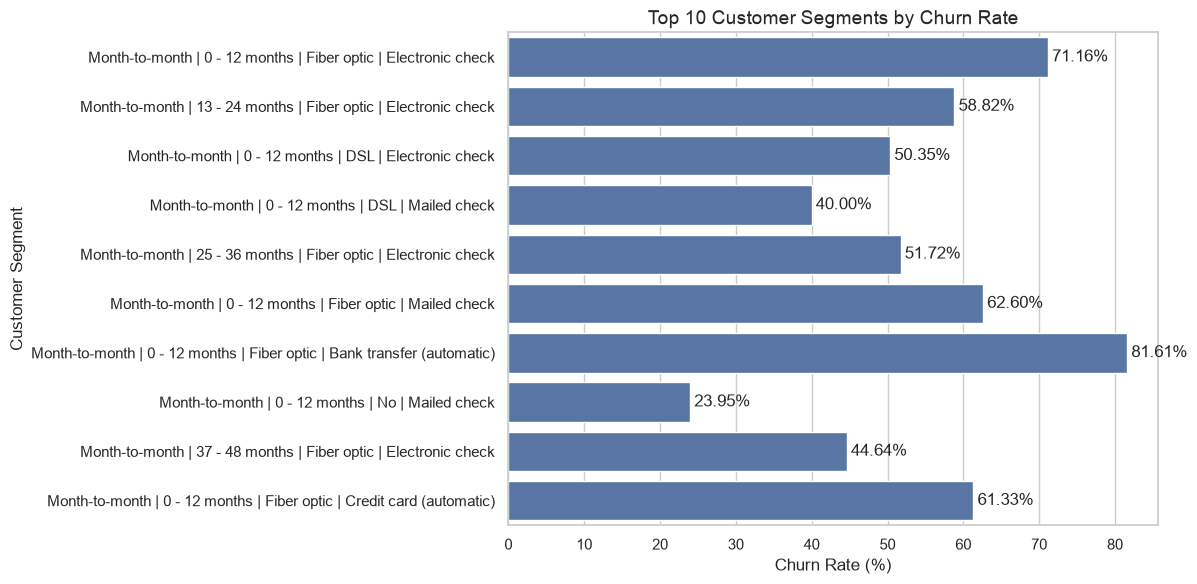

In [72]:
plot_top_segments(
    priority_segments,
    grouping_columns=[
        "Contract",
        "Tenure Band",
        "Internet Service",
        "Payment Method"
    ]
)

### Business Insight

The customer segments that should be prioritized for retention are those combining large customer populations with high churn rates, as they account for the greatest number of customers lost.

- The highest-priority segment consists of customers on month-to-month contracts, within their first year of tenure, using Fiber optic internet, and paying through Electronic Check, contributing the largest number of churned customers (449).
- Several other high-priority segments share similar characteristics, particularly month-to-month contracts combined with Fiber optic internet and Electronic Check payments.
- While some smaller customer segments exhibit even higher churn rates, their overall business impact is considerably lower due to their limited customer base.
- Prioritizing retention based on both churn volume and churn rate enables the business to maximize the impact of retention initiatives.

Overall, the findings indicate that retention campaigns should focus first on large, high-risk customer segments where reducing churn will preserve the greatest number of customers and generate the highest business value.

# Exploratory Data Analysis Conclusion

The exploratory data analysis provided a comprehensive understanding of the customer base and identified the primary factors associated with customer churn.

### Key Findings

- The overall customer churn rate is approximately **26.5%**, indicating that roughly one in four customers discontinue the service.

- **Contract type** emerged as the strongest indicator of churn. Customers on month-to-month contracts consistently experienced substantially higher churn rates than those with one-year or two-year contracts.

- **Customer tenure** showed a strong inverse relationship with churn. Customers were most likely to leave during the first year of their subscription, while long-tenure customers demonstrated significantly higher retention.

- Customers subscribed to **Fiber optic internet** experienced the highest churn rates across multiple analyses, suggesting potential issues related to pricing, service quality, or customer expectations.

- Customers without **Online Security** or **Tech Support** exhibited considerably higher churn rates, indicating that value-added services contribute positively to customer retention.

- **Electronic Check** was consistently associated with higher churn compared to automatic payment methods, suggesting that payment behavior may reflect differences in customer engagement or commitment.

- Customers with **higher monthly charges** generally showed higher churn, while customers with greater **lifetime spending (Total Charges)** exhibited lower churn, largely reflecting the stabilizing effect of longer customer tenure.

- Demographic characteristics such as **Gender**, along with services like **Phone Service** and **Multiple Lines**, demonstrated relatively weak relationships with customer churn.

### Bivariate Analysis

The interaction between key variables revealed several important patterns.

- Customers with **month-to-month contracts** remained the highest-risk group regardless of tenure, although churn decreased as tenure increased.
- The combination of **Fiber optic internet** with the absence of **Online Security** or **Tech Support** resulted in substantially higher churn rates than other internet service groups.
- High monthly charges became particularly problematic when combined with **month-to-month contracts**, reinforcing the importance of customer commitment alongside pricing.

### Customer Segment Analysis

Segment-level analysis identified specific customer groups that should receive the greatest business attention.

- The highest-risk customer segments were primarily customers with **month-to-month contracts**, **Fiber optic internet**, **short tenure**, and **Electronic Check** payment methods.
- The most stable customer segments consisted of customers with **two-year contracts**, **long tenure**, and, in many cases, **no internet service**.
- High-value customers were not immune to churn. Customers with higher monthly charges still exhibited elevated churn when they remained on flexible contracts and subscribed to Fiber optic internet.
- The highest-priority retention segment consisted of customers on **month-to-month contracts**, within their first year of tenure, using **Fiber optic internet** and **Electronic Check** payments, as this group combined both a large customer base and a high churn rate.

### Overall Conclusion

The exploratory analysis indicates that customer churn is primarily driven by **customer commitment, service experience, and account behavior**, rather than demographic characteristics.

Across the analyses, **contract type**, **tenure**, **internet service type**, **Online Security**, **Tech Support**, and **payment method** consistently emerged as the strongest indicators of churn. These findings suggest that retention strategies should focus on strengthening customer commitment during the early stages of the customer lifecycle, improving the experience of Fiber optic customers, and encouraging the adoption of long-term contracts and value-added services.

The findings from this exploratory analysis establish clear hypotheses regarding the factors influencing customer churn. The next stage of the project will use statistical analysis to validate whether these observed relationships are statistically significant before proceeding to predictive modeling.